In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv
/kaggle/input/global-weather-repository/state.db


In [2]:
df = pd.read_csv("/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86713 entries, 0 to 86712
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       86713 non-null  object 
 1   location_name                 86713 non-null  object 
 2   latitude                      86713 non-null  float64
 3   longitude                     86713 non-null  float64
 4   timezone                      86713 non-null  object 
 5   last_updated_epoch            86713 non-null  int64  
 6   last_updated                  86713 non-null  object 
 7   temperature_celsius           86713 non-null  float64
 8   temperature_fahrenheit        86713 non-null  float64
 9   condition_text                86713 non-null  object 
 10  wind_mph                      86713 non-null  float64
 11  wind_kph                      86713 non-null  float64
 12  wind_degree                   86713 non-null  int64  
 13  w

In [4]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,86713.000000,86713.000000,8.671300e+04,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,...,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000,86713.000000
mean,19.126182,22.174152,1.735160e+09,22.636070,72.746618,8.306082,13.370619,170.643560,1013.956800,29.941509,...,18.797705,517.212207,63.806247,15.422934,11.324932,26.184348,54.374647,1.759125,2.768743,49.970316
std,24.471079,65.835249,1.115495e+07,9.116501,16.409465,8.186655,13.172918,103.180923,11.859298,0.350154,...,15.167012,862.624424,33.213667,25.915003,42.544186,41.602663,163.819178,0.988493,2.591818,34.948152
min,-41.300000,-175.200000,1.715849e+09,-24.900000,-12.800000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.750000,-6.836100,1.725538e+09,17.700000,63.900000,4.000000,6.500000,82.000000,1010.000000,29.830000,...,10.700000,234.950000,43.000000,1.224000,0.800000,7.030000,10.360000,1.000000,1.000000,15.000000
50%,17.250000,23.316700,1.735208e+09,25.000000,77.000000,6.900000,11.200000,164.000000,1013.000000,29.920000,...,16.200000,325.600000,61.000000,4.440000,2.405000,14.900000,21.905000,1.000000,2.000000,50.000000
75%,40.400000,50.580000,1.744794e+09,28.400000,83.100000,11.400000,18.400000,257.000000,1017.000000,30.040000,...,24.900000,505.050000,81.000000,17.205000,9.065000,30.340000,46.990000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.754383e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [5]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

df['month'] = df['last_updated'].dt.month
df['hour'] = df['last_updated'].dt.hour


df.drop(columns=["last_updated"], inplace=True)

df['condition_text'] = df['condition_text'].replace('Partly cloudy', 'Partly Cloudy')
df = df[df['condition_text'] != 'Patchy snow possible']

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

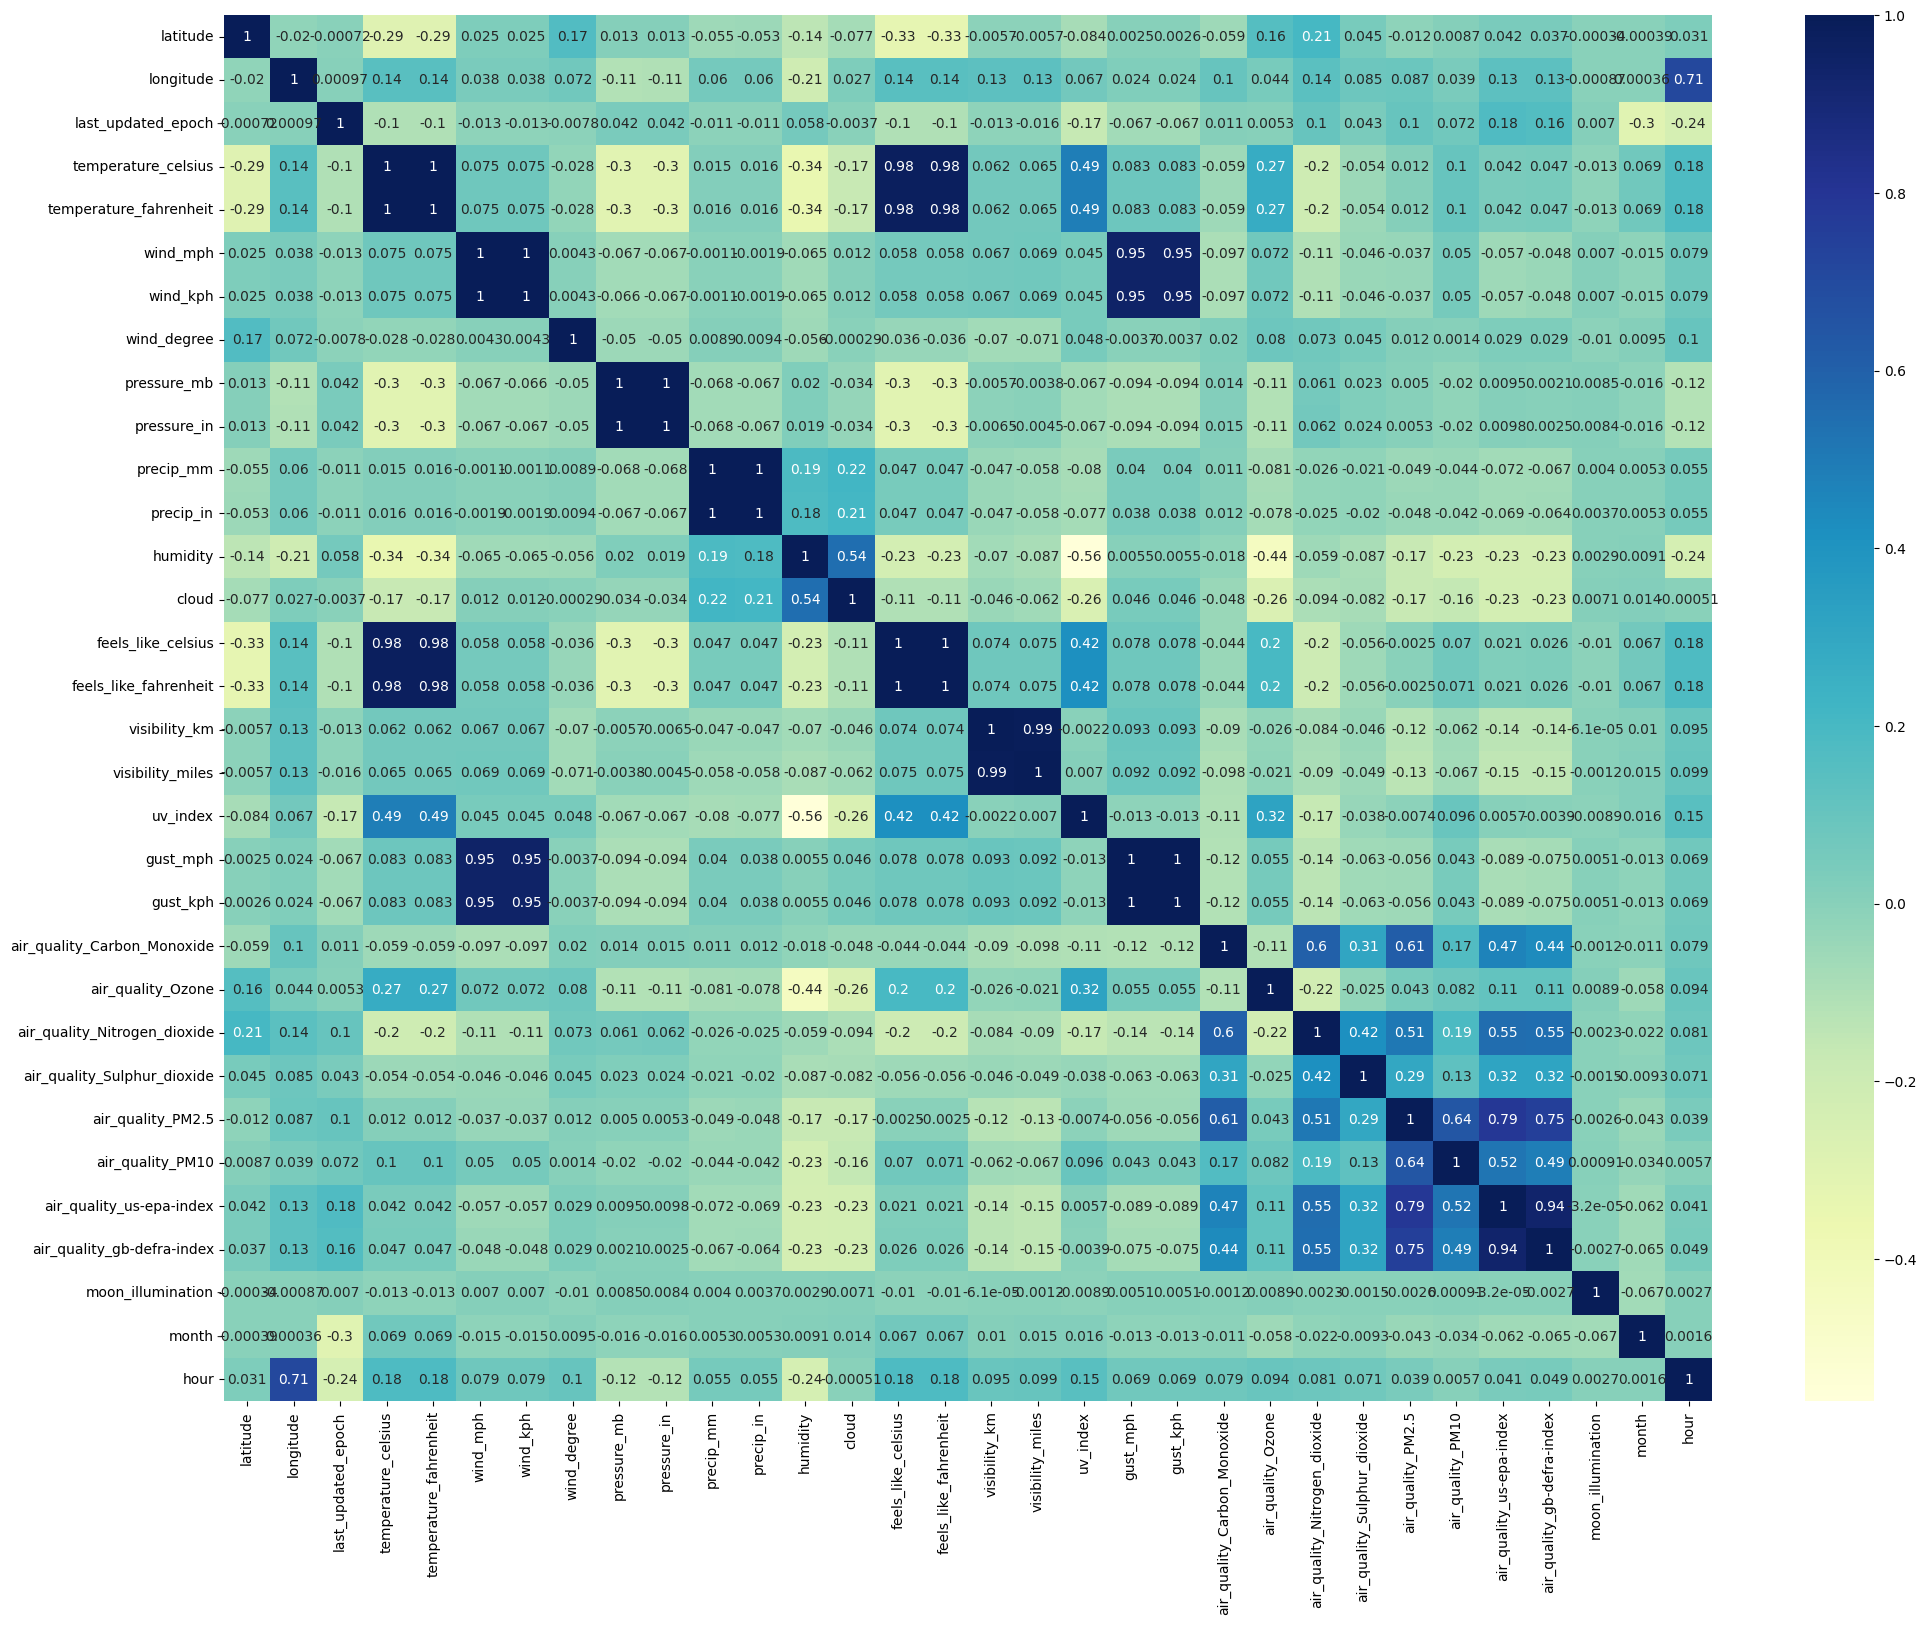

In [7]:
plt.figure(figsize=(24, 18))
co_mtx = df.corr(numeric_only=True)
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.show()

In [8]:
df['condition_text'].value_counts().sort_index()

condition_text
Blizzard                                           5
Blowing snow                                      20
Clear                                           3722
Cloudy                                           823
Fog                                              816
Freezing drizzle                                   2
Freezing fog                                      54
Heavy rain                                        38
Heavy rain at times                               10
Heavy snow                                        58
Light drizzle                                    373
Light freezing rain                               35
Light rain                                      2541
Light rain shower                               2135
Light sleet                                       33
Light sleet showers                                7
Light snow                                       189
Light snow showers                                42
Mist                           

In [9]:
df.drop(columns=["country"], inplace=True)
df.drop(columns=["timezone"], inplace=True)
df.drop(columns=["moon_phase"], inplace=True)
df.drop(columns=["sunrise"], inplace=True)
df.drop(columns=["sunset"], inplace=True)
df.drop(columns=["moonrise"], inplace=True)
df.drop(columns=["moonset"], inplace=True)
df.drop(columns=["moon_illumination"], inplace=True)
df.drop(columns=["last_updated_epoch"], inplace=True)
df.drop(columns=["location_name"], inplace=True)


df.drop(columns=["temperature_fahrenheit"], inplace=True)
df.drop(columns=["wind_mph"], inplace=True)
df.drop(columns=["wind_direction"], inplace=True)
df.drop(columns=["pressure_in"], inplace=True)
df.drop(columns=["precip_in"], inplace=True)
df.drop(columns=["feels_like_fahrenheit"], inplace=True)
df.drop(columns=["visibility_miles"], inplace=True)
df.drop(columns=["gust_mph"], inplace=True)
df.drop(columns=["air_quality_us-epa-index"], inplace=True)
df.drop(columns=["feels_like_celsius"], inplace=True)
df.drop(columns=["gust_kph"], inplace=True)
df.drop(columns=["air_quality_PM2.5"], inplace=True)
df.drop(columns=["air_quality_gb-defra-index"], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86712 entries, 0 to 86712
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   latitude                      86712 non-null  float64
 1   longitude                     86712 non-null  float64
 2   temperature_celsius           86712 non-null  float64
 3   condition_text                86712 non-null  object 
 4   wind_kph                      86712 non-null  float64
 5   wind_degree                   86712 non-null  int64  
 6   pressure_mb                   86712 non-null  float64
 7   precip_mm                     86712 non-null  float64
 8   humidity                      86712 non-null  int64  
 9   cloud                         86712 non-null  int64  
 10  visibility_km                 86712 non-null  float64
 11  uv_index                      86712 non-null  float64
 12  air_quality_Carbon_Monoxide   86712 non-null  float64
 13  air_qu

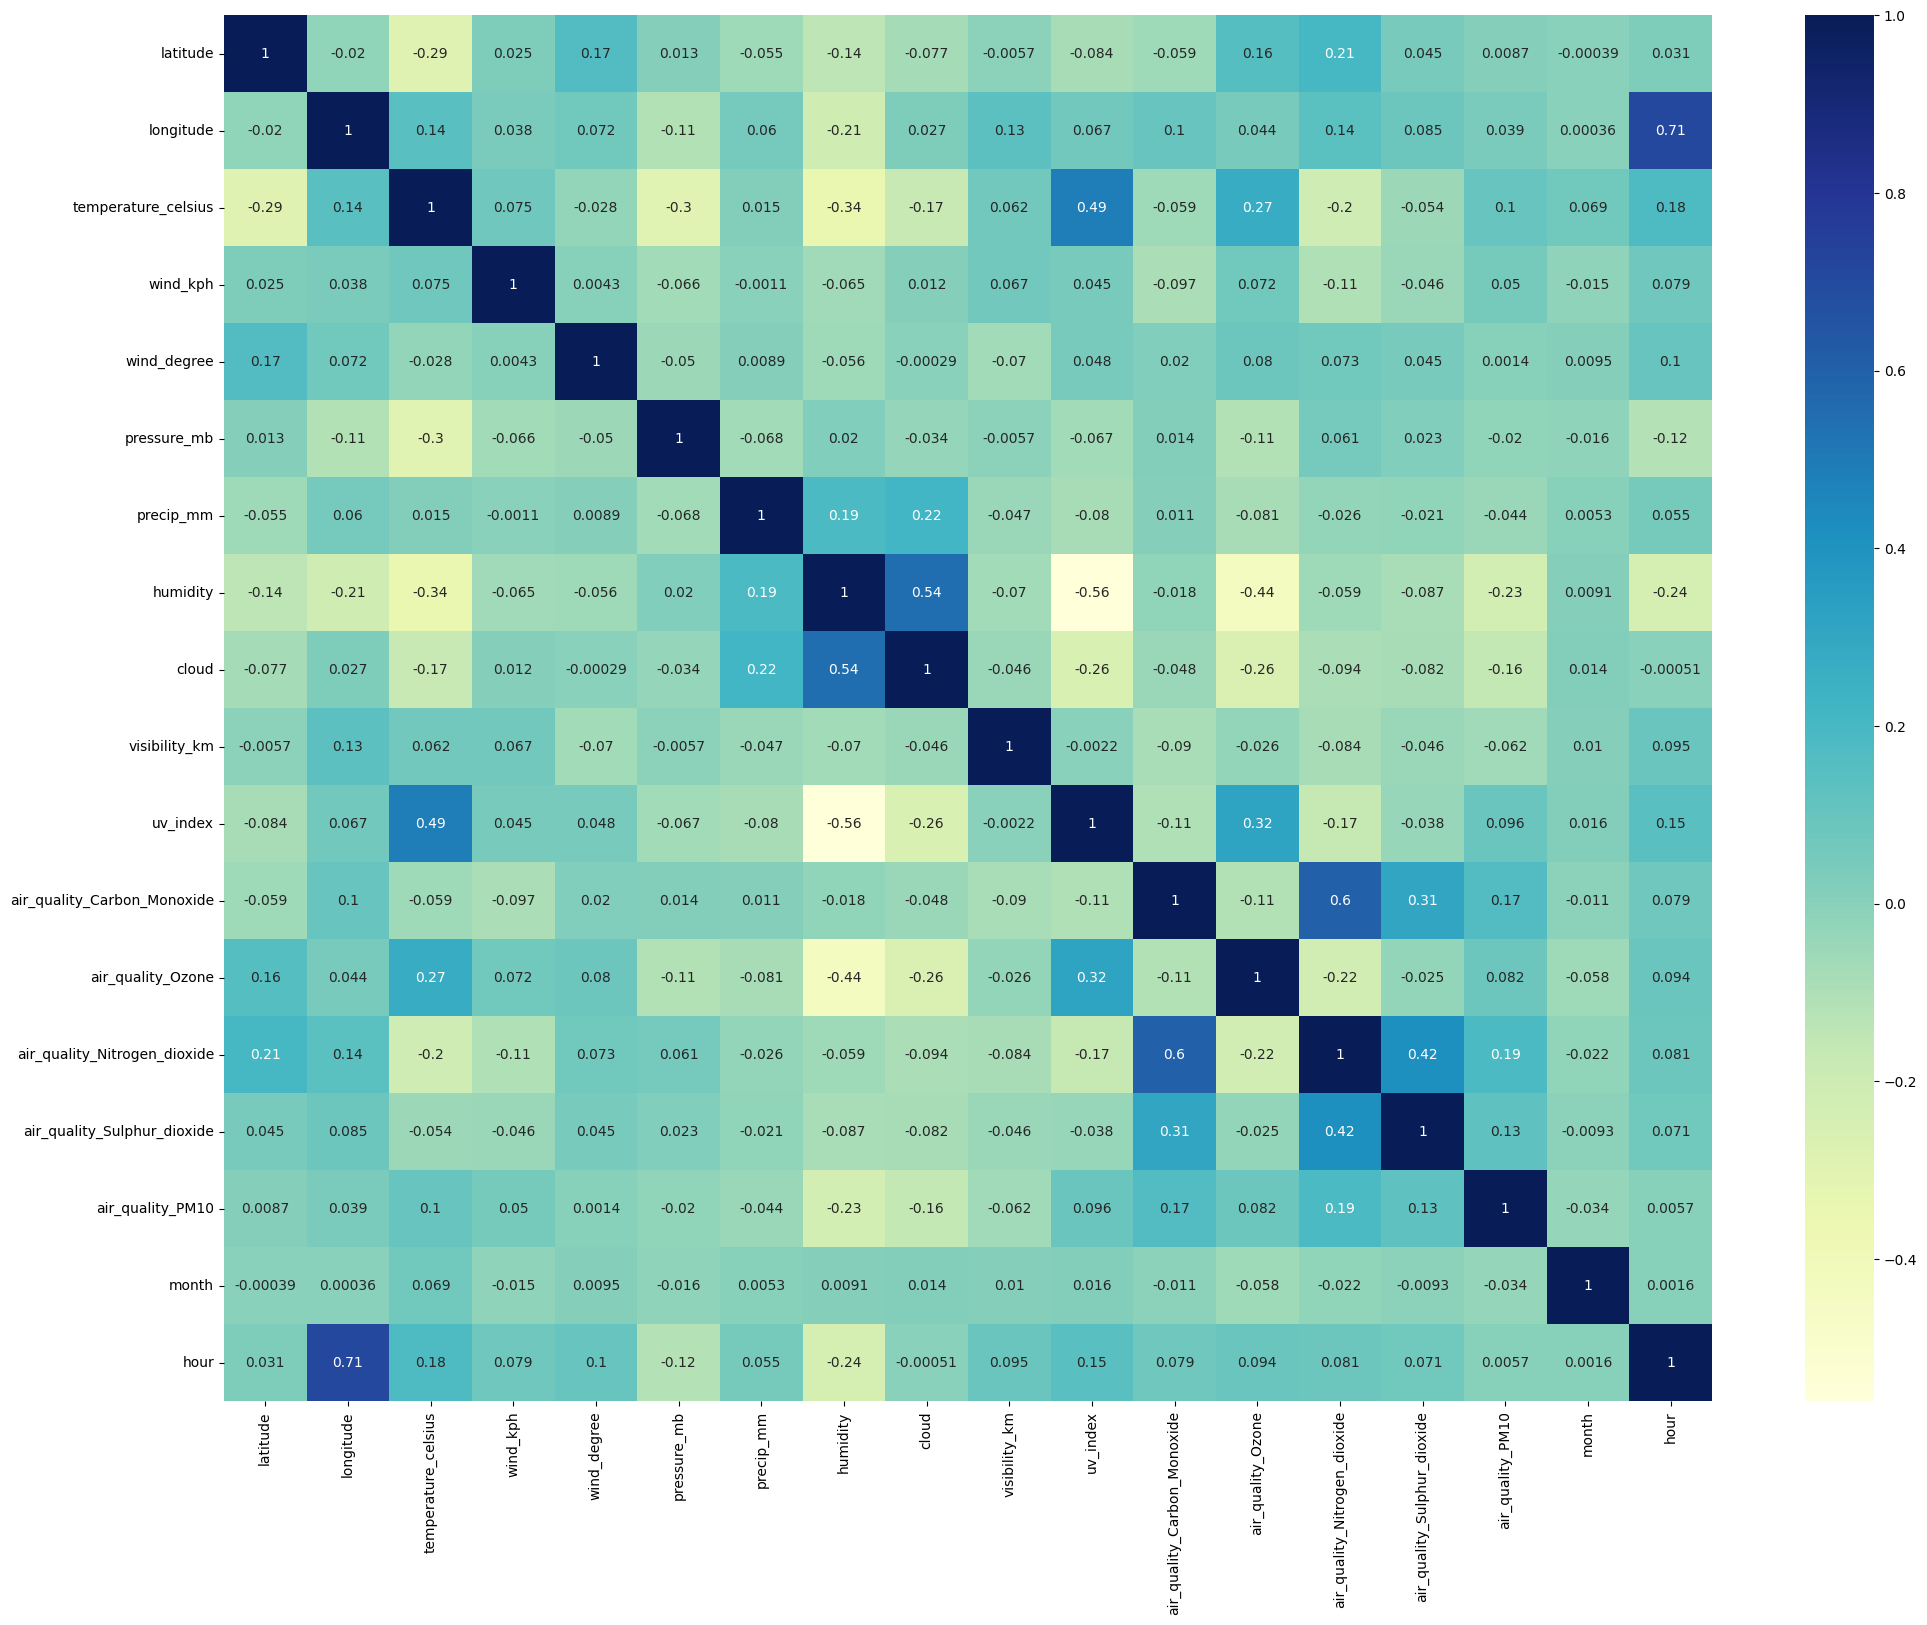

In [11]:
plt.figure(figsize=(24, 18))
co_mtx = df.corr(numeric_only=True)
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.show()

In [12]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [13]:
X = df.drop('condition_text', axis=1)
y = df['condition_text']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [14]:
print("Tüm sınıflar (y_encoded):", np.unique(y_encoded))
print("Eğitimdeki sınıflar (y_train):", np.unique(y_train))

Tüm sınıflar (y_encoded): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]
Eğitimdeki sınıflar (y_train): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]


In [15]:
num_classes = len(np.unique(y_encoded))

model = XGBClassifier(
    objective='multi:softmax', 
    n_estimators=100,            
    learning_rate=0.1,           
    max_depth=35,                 
    use_label_encoder=False,     
    eval_metric='mlogloss',
    num_class=num_classes
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=35,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=45, num_parallel_tree=None, ...)

In [16]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  0   0   0 ...   0   0   0]
 [  0   1   0 ...   0   0   0]
 [  0   0 688 ...   0   0   0]
 ...
 [  0   0   1 ...  17   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.33      0.50         3
           2       0.92      0.93      0.93       738
           3       0.97      0.79      0.87       159
           4       0.90      0.85      0.87       150
           5       0.00      0.00      0.00         1
           6       0.60      0.50      0.55        12
           7       0.67      0.50      0.57         8
           8       1.00      0.50      0.67         2
           9       0.83      0.91      0.87        11
          10       0.89      0.45      0.60        87
          11       0.33      0.14      0.20         7
          12       0.48      0.32      0.39       512
          13       0.90      0.82      0.86       4

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


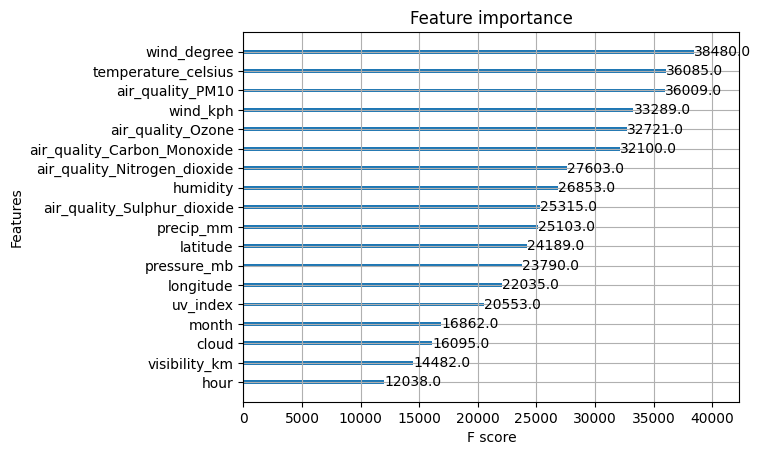

In [17]:
xgb.plot_importance(model)
plt.show()

In [18]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Doğruluk: {acc:.4f}")

Doğruluk: 0.8951


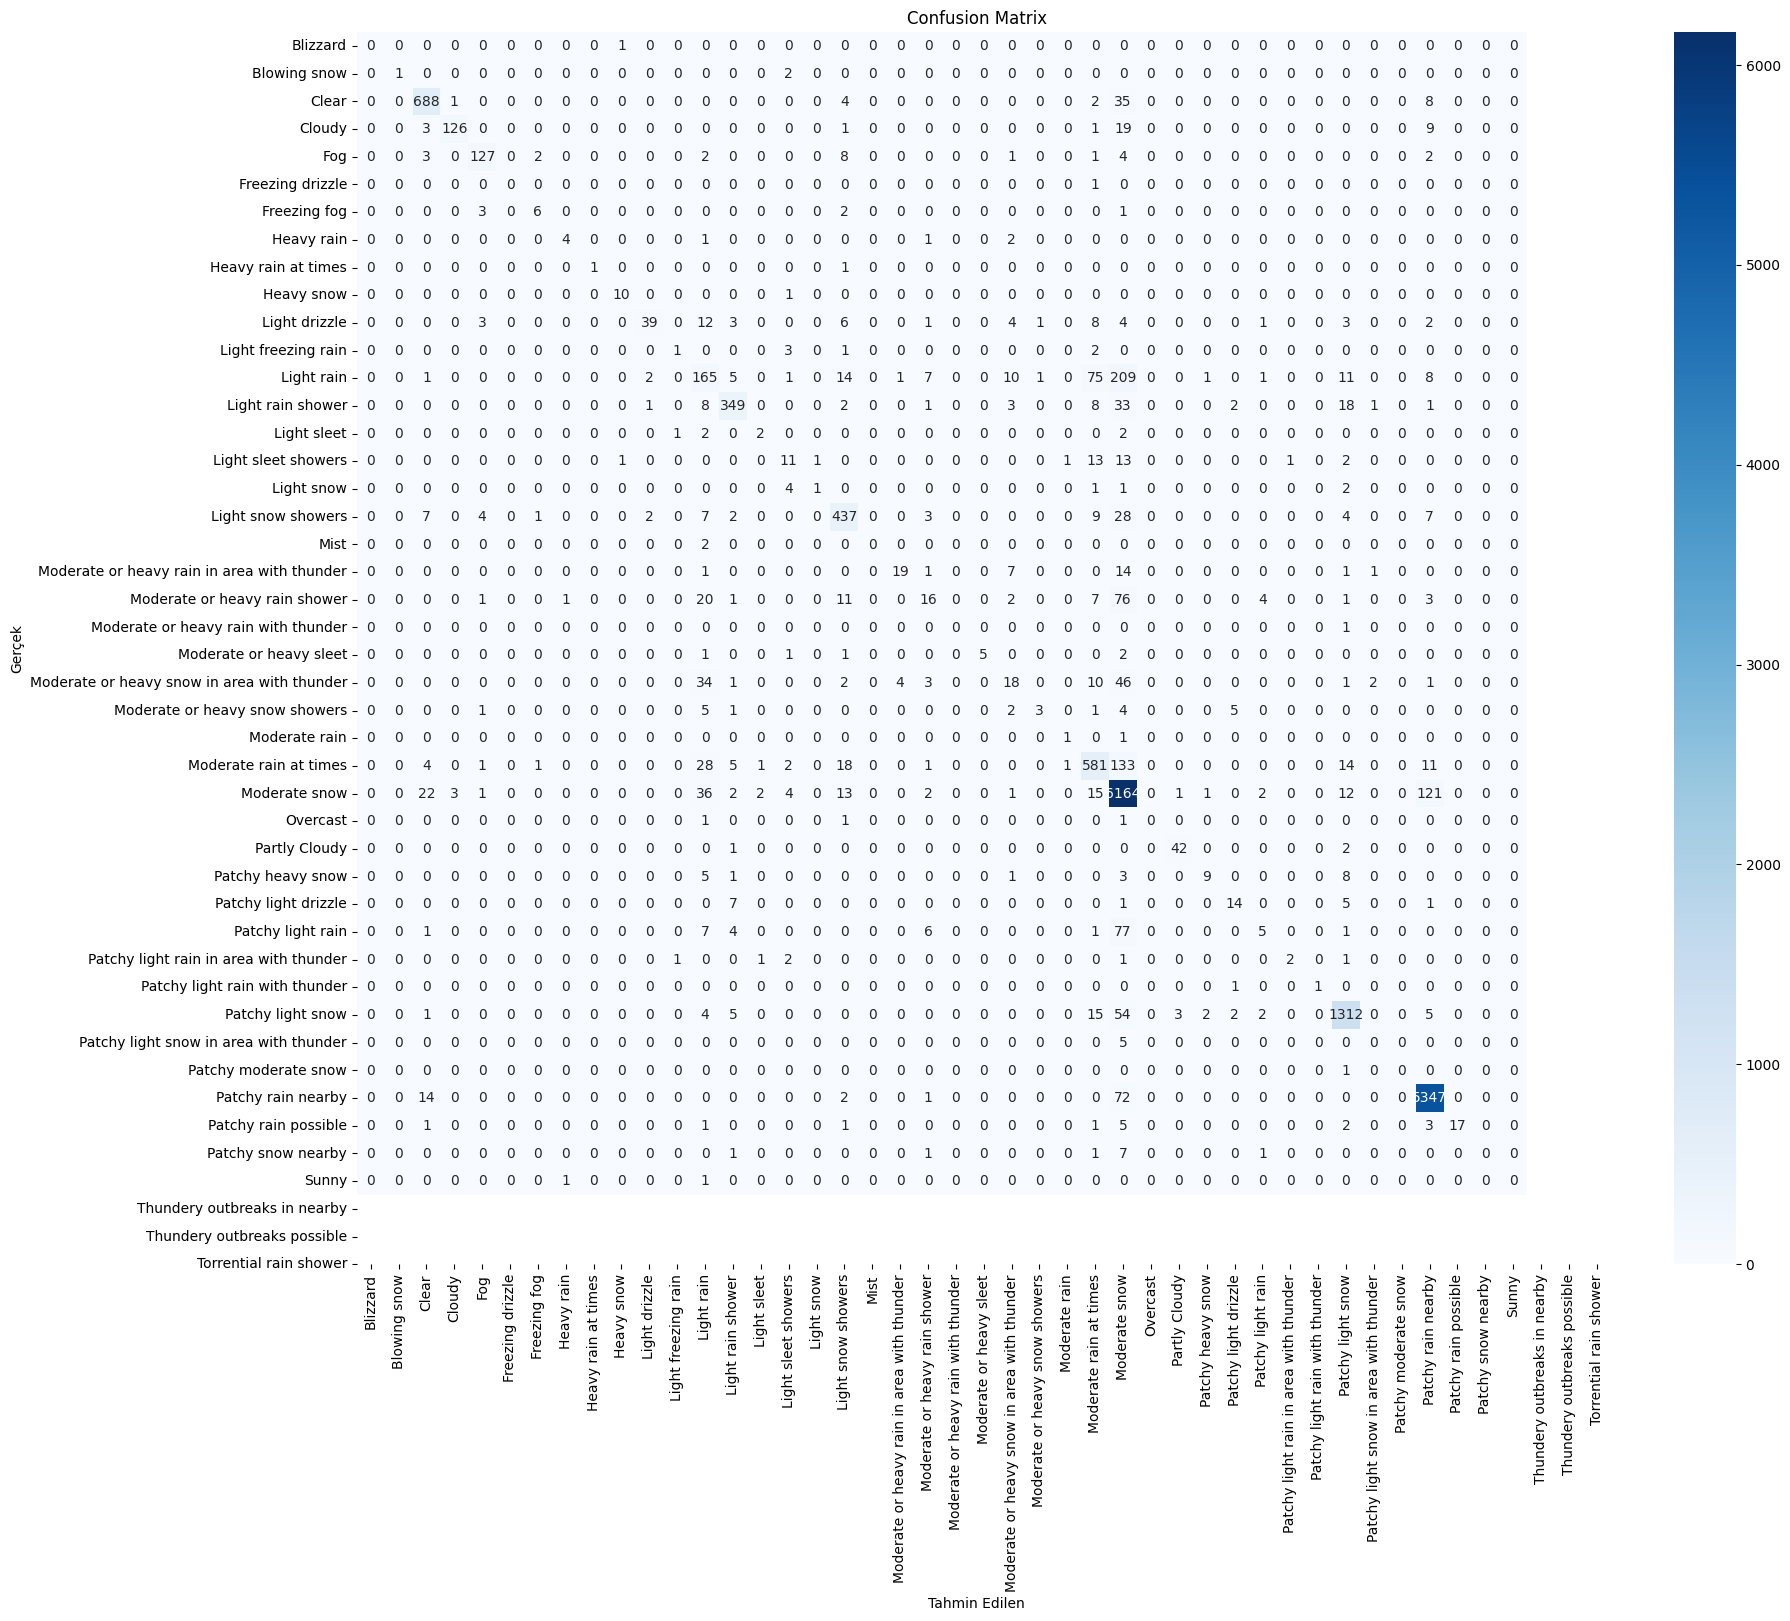

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()